<a href="https://colab.research.google.com/github/gocleanwater/AI-class/blob/main/week3/wineRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

In [15]:
path = '/content/drive/MyDrive/Colab Notebooks/AI-class/week3/wine.csv'

df = pd.read_csv(path)
df

,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [16]:
df2=df.drop('Wine',axis=1)
df2.head()

,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


count    178.000000
mean      13.000618
std        0.811827
min       11.030000
25%       12.362500
50%       13.050000
75%       13.677500
max       14.830000
Name: Alcohol, dtype: float64
Axes(0.125,0.11;0.775x0.77)


,Alcohol
0,14.23
1,13.20
2,13.16
3,14.37
4,13.24
...,...
173,13.71
174,13.40
175,13.27
176,13.17


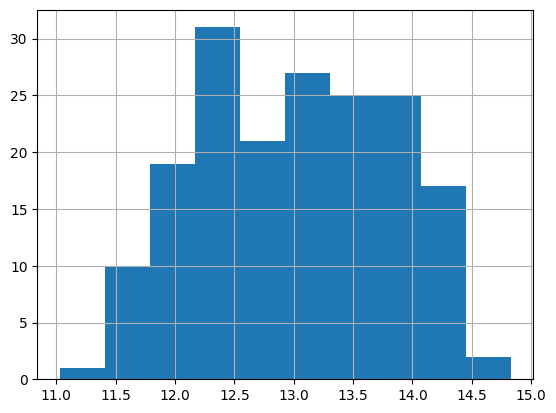

In [17]:
y=df2['Alcohol']
print(y.describe())
print(y.hist())
y

In [18]:
x=df2.drop('Alcohol',axis=1)
x.head()

,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.25,random_state=0)

In [20]:
# Linear Regression 방식
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_ly = LinearRegression()
model_ly.fit(x_train, y_train)
ly_preds = model_ly.predict(x_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 0.4016852023007239
평균제곱오차 0.4016852023007239
평균제곱오차 0.40168520230072396


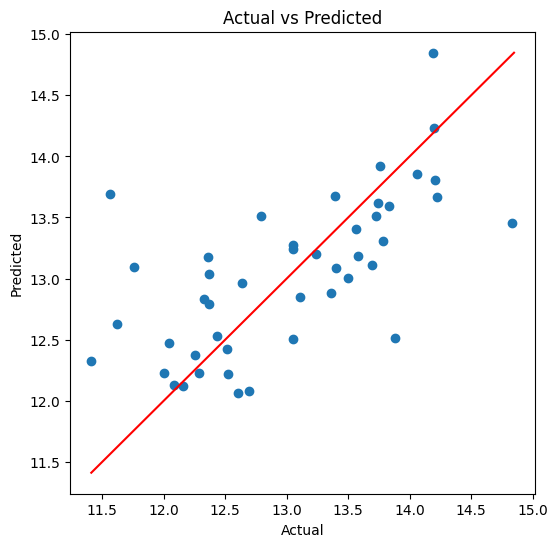

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, ly_preds)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted')

min_val = min(y_test.min(), ly_preds.min())
max_val = max(y_test.max(), ly_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.show()

In [22]:
# Decision Tree Regressor 방식
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

model_lr = DecisionTreeRegressor()

model_lr.fit(x_train, y_train)
ly_preds = model_lr.predict(x_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 0.6048844444444444
평균제곱오차 0.6048844444444444
평균제곱오차 0.6048844444444447


In [23]:
# Random Forest Regressor 방식
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

model_lr = RandomForestRegressor()

model_lr.fit(x_train, y_train)
ly_preds = model_lr.predict(x_test)

print('평균제곱오차', mean_squared_error(y_test, ly_preds))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱오차', mse_np(y_test, ly_preds))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱오차', mse(y_test, ly_preds))

평균제곱오차 0.4695935788888862
평균제곱오차 0.4695935788888862
평균제곱오차 0.46959357888888614
